# SNMP Linux Metrics Data Exploration and Visualization

This notebook explores and visualizes SNMP Linux metrics data from the MySQL database.
The data structure includes:
- devices: Device information (sysname, ip_address, online status)
- system_info: System information (location, uptime)
- load_avg: Load averages (1m, 5m, 15m)
- cpu_percent: CPU usage per core
- memory: Memory usage statistics
- swap_memory: Swap memory statistics
- disk_usage: Disk usage per mount point
- disk_io_counters: Disk I/O statistics
- net_io_counters: Network I/O statistics
- temperature: CPU temperature

This exploration will help understand data patterns for later web app visualization.

In [55]:
import os
import sys
from typing import List, Dict, Optional, Tuple
from datetime import datetime, timedelta
from contextlib import contextmanager

import pymysql
from pymysql.cursors import DictCursor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pydantic import BaseModel, Field

# Add query-service to path for imports
# Handle both script and notebook contexts
try:
    # When running as a script, use __file__
    current_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # When running in Jupyter notebook, use current working directory
    current_dir = os.getcwd()

query_service_path = os.path.join(current_dir, 'query-service')
if os.path.exists(query_service_path):
    if query_service_path not in sys.path:
        sys.path.insert(0, query_service_path)
    print(f"[DEBUG] Added {query_service_path} to Python path")
else:
    print(f"[WARNING] query-service directory not found at {query_service_path}")
    print(f"[DEBUG] Current directory: {current_dir}")
    print(f"[DEBUG] Working directory: {os.getcwd()}")
    # Try using working directory as fallback
    alt_path = os.path.join(os.getcwd(), 'query-service')
    if os.path.exists(alt_path) and alt_path not in sys.path:
        sys.path.insert(0, alt_path)
        print(f"[DEBUG] Using alternative path: {alt_path}")

from config import DB_HOST, DB_PORT, DB_USER, DB_PASSWORD, DB_NAME

print("[DEBUG] Imports completed successfully")

[DEBUG] Added c:\Users\LAPTOP T&T\VIOLETTA\Documents\MQF\StudyMaterial\Third year\5th Semester\PBL4\projects\query-service to Python path
[DEBUG] Imports completed successfully


## Database Connection Setup

Pure function to create database connection with strict typing.

In [56]:
def create_connection() -> pymysql.Connection:
    """Create a database connection with DictCursor."""
    print(f"[DEBUG] Creating connection to {DB_HOST}:{DB_PORT}/{DB_NAME}")
    return pymysql.connect(
        host=DB_HOST,
        port=DB_PORT,
        user=DB_USER,
        password=DB_PASSWORD,
        database=DB_NAME,
        cursorclass=DictCursor,
        autocommit=True,
    )

@contextmanager
def get_db():
    """Context manager for database connections."""
    conn: pymysql.Connection = create_connection()
    try:
        yield conn
    finally:
        conn.close()

## Data Models

Using Pydantic models for type-safe data structures.

In [57]:
class DeviceInfo(BaseModel):
    """Device information model."""
    sysname: str = Field(..., description="System name identifier")
    ip_address: Optional[str] = Field(None, description="IP address")
    last_seen: Optional[datetime] = Field(None, description="Last seen timestamp")
    online: bool = Field(False, description="Online status")

class SystemInfo(BaseModel):
    """System information model."""
    sysname: str
    sys_location: Optional[str] = None
    sys_uptime: Optional[int] = None
    time: Optional[datetime] = None

class LoadAvg(BaseModel):
    """Load average model."""
    sysname: str
    time: datetime
    load_1m: Optional[float] = None
    load_5m: Optional[float] = None
    load_15m: Optional[float] = None

class CpuPercent(BaseModel):
    """CPU percent model."""
    sysname: str
    time: datetime
    cpu: str
    percent: Optional[float] = None

class Memory(BaseModel):
    """Memory usage model."""
    sysname: str
    time: datetime
    total: Optional[int] = None
    available: Optional[int] = None
    used: Optional[int] = None
    free: Optional[int] = None
    percent: Optional[float] = None
    buffers: Optional[int] = None
    cached: Optional[int] = None
    shared: Optional[int] = None

class SwapMemory(BaseModel):
    """Swap memory model."""
    sysname: str
    time: datetime
    total: Optional[int] = None
    used: Optional[int] = None
    free: Optional[int] = None
    percent: Optional[float] = None

class DiskUsage(BaseModel):
    """Disk usage model."""
    sysname: str
    time: datetime
    mount: Optional[str] = None
    device_partition: Optional[str] = None
    total: Optional[int] = None
    used: Optional[int] = None
    free: Optional[int] = None
    percent: Optional[float] = None

class DiskIOCounters(BaseModel):
    """Disk I/O counters model."""
    sysname: str
    time: datetime
    disk: Optional[str] = None
    read_count: Optional[int] = None
    write_count: Optional[int] = None
    read_bytes: Optional[int] = None
    write_bytes: Optional[int] = None

class NetIOCounters(BaseModel):
    """Network I/O counters model."""
    sysname: str
    time: datetime
    iface: Optional[str] = None
    if_index: Optional[int] = None
    bytes_sent: Optional[int] = None
    bytes_recv: Optional[int] = None
    if_admin_status: Optional[int] = None
    if_oper_status: Optional[int] = None

class Temperature(BaseModel):
    """Temperature model."""
    sysname: str
    time: datetime
    cpu_temp: Optional[float] = None

print("[DEBUG] Data models defined")

[DEBUG] Data models defined


## Data Loading Functions

Pure functions to load data from database into pandas DataFrames.

In [58]:
def load_devices() -> pd.DataFrame:
    """Load all devices from database."""
    print("[DEBUG] Loading devices data")
    with get_db() as conn:
        with conn.cursor() as cur:
            cur.execute("SELECT sysname, ip_address, last_seen, online, created_at, updated_at FROM devices")
            rows: List[Dict] = cur.fetchall()
            df: pd.DataFrame = pd.DataFrame(rows)
            if not df.empty:
                df['last_seen'] = pd.to_datetime(df['last_seen'])
                df['created_at'] = pd.to_datetime(df['created_at'])
                df['updated_at'] = pd.to_datetime(df['updated_at'])
            print(f"[DEBUG] Loaded {len(df)} devices")
            return df

def load_system_info(sysname: Optional[str] = None) -> pd.DataFrame:
    """Load system info for device(s)."""
    print(f"[DEBUG] Loading system info for sysname={sysname}")
    with get_db() as conn:
        with conn.cursor() as cur:
            if sysname:
                cur.execute("SELECT * FROM system_info WHERE sysname = %s", (sysname,))
            else:
                cur.execute("SELECT * FROM system_info")
            rows: List[Dict] = cur.fetchall()
            df: pd.DataFrame = pd.DataFrame(rows)
            if not df.empty:
                df['time'] = pd.to_datetime(df['time'])
            print(f"[DEBUG] Loaded {len(df)} system info records")
            return df

def load_load_avg(sysname: Optional[str] = None, hours: Optional[int] = 24) -> pd.DataFrame:
    """Load load average data for device(s) within time range."""
    print(f"[DEBUG] Loading load_avg for sysname={sysname}, hours={hours}")
    with get_db() as conn:
        with conn.cursor() as cur:
            if hours is not None:
                cutoff: datetime = datetime.now() - timedelta(hours=hours)
                if sysname:
                    cur.execute(
                        "SELECT * FROM load_avg WHERE sysname = %s AND time >= %s ORDER BY time",
                        (sysname, cutoff)
                    )
                else:
                    cur.execute(
                        "SELECT * FROM load_avg WHERE time >= %s ORDER BY time",
                        (cutoff,)
                    )
            else:
                # No time filter - get all data
                if sysname:
                    cur.execute(
                        "SELECT * FROM load_avg WHERE sysname = %s ORDER BY time",
                        (sysname,)
                    )
                else:
                    cur.execute("SELECT * FROM load_avg ORDER BY time")
            rows: List[Dict] = cur.fetchall()
            df: pd.DataFrame = pd.DataFrame(rows)
            if not df.empty:
                df['time'] = pd.to_datetime(df['time'])
            print(f"[DEBUG] Loaded {len(df)} load_avg records")
            if not df.empty:
                print(f"  Time range: {df['time'].min()} to {df['time'].max()}")
            return df

def load_cpu_percent(sysname: Optional[str] = None, hours: Optional[int] = 24) -> pd.DataFrame:
    """Load CPU percent data for device(s) within time range."""
    print(f"[DEBUG] Loading cpu_percent for sysname={sysname}, hours={hours}")
    with get_db() as conn:
        with conn.cursor() as cur:
            if hours is not None:
                cutoff: datetime = datetime.now() - timedelta(hours=hours)
                if sysname:
                    cur.execute(
                        "SELECT * FROM cpu_percent WHERE sysname = %s AND time >= %s ORDER BY time",
                        (sysname, cutoff)
                    )
                else:
                    cur.execute(
                        "SELECT * FROM cpu_percent WHERE time >= %s ORDER BY time",
                        (cutoff,)
                    )
            else:
                if sysname:
                    cur.execute(
                        "SELECT * FROM cpu_percent WHERE sysname = %s ORDER BY time",
                        (sysname,)
                    )
                else:
                    cur.execute("SELECT * FROM cpu_percent ORDER BY time")
            rows: List[Dict] = cur.fetchall()
            df: pd.DataFrame = pd.DataFrame(rows)
            if not df.empty:
                df['time'] = pd.to_datetime(df['time'])
            print(f"[DEBUG] Loaded {len(df)} cpu_percent records")
            if not df.empty:
                print(f"  Time range: {df['time'].min()} to {df['time'].max()}")
            return df

def load_memory(sysname: Optional[str] = None, hours: Optional[int] = 24) -> pd.DataFrame:
    """Load memory data for device(s) within time range."""
    print(f"[DEBUG] Loading memory for sysname={sysname}, hours={hours}")
    with get_db() as conn:
        with conn.cursor() as cur:
            if hours is not None:
                cutoff: datetime = datetime.now() - timedelta(hours=hours)
                if sysname:
                    cur.execute(
                        "SELECT * FROM memory WHERE sysname = %s AND time >= %s ORDER BY time",
                        (sysname, cutoff)
                    )
                else:
                    cur.execute(
                        "SELECT * FROM memory WHERE time >= %s ORDER BY time",
                        (cutoff,)
                    )
            else:
                if sysname:
                    cur.execute(
                        "SELECT * FROM memory WHERE sysname = %s ORDER BY time",
                        (sysname,)
                    )
                else:
                    cur.execute("SELECT * FROM memory ORDER BY time")
            rows: List[Dict] = cur.fetchall()
            df: pd.DataFrame = pd.DataFrame(rows)
            if not df.empty:
                df['time'] = pd.to_datetime(df['time'])
            print(f"[DEBUG] Loaded {len(df)} memory records")
            if not df.empty:
                print(f"  Time range: {df['time'].min()} to {df['time'].max()}")
            return df

def load_swap_memory(sysname: Optional[str] = None, hours: Optional[int] = 24) -> pd.DataFrame:
    """Load swap memory data for device(s) within time range."""
    print(f"[DEBUG] Loading swap_memory for sysname={sysname}, hours={hours}")
    with get_db() as conn:
        with conn.cursor() as cur:
            if hours is not None:
                cutoff: datetime = datetime.now() - timedelta(hours=hours)
                if sysname:
                    cur.execute(
                        "SELECT * FROM swap_memory WHERE sysname = %s AND time >= %s ORDER BY time",
                        (sysname, cutoff)
                    )
                else:
                    cur.execute(
                        "SELECT * FROM swap_memory WHERE time >= %s ORDER BY time",
                        (cutoff,)
                    )
            else:
                if sysname:
                    cur.execute(
                        "SELECT * FROM swap_memory WHERE sysname = %s ORDER BY time",
                        (sysname,)
                    )
                else:
                    cur.execute("SELECT * FROM swap_memory ORDER BY time")
            rows: List[Dict] = cur.fetchall()
            df: pd.DataFrame = pd.DataFrame(rows)
            if not df.empty:
                df['time'] = pd.to_datetime(df['time'])
            print(f"[DEBUG] Loaded {len(df)} swap_memory records")
            if not df.empty:
                print(f"  Time range: {df['time'].min()} to {df['time'].max()}")
            return df

def load_disk_usage(sysname: Optional[str] = None, hours: Optional[int] = 24) -> pd.DataFrame:
    """Load disk usage data for device(s) within time range."""
    print(f"[DEBUG] Loading disk_usage for sysname={sysname}, hours={hours}")
    with get_db() as conn:
        with conn.cursor() as cur:
            if hours is not None:
                cutoff: datetime = datetime.now() - timedelta(hours=hours)
                if sysname:
                    cur.execute(
                        "SELECT * FROM disk_usage WHERE sysname = %s AND time >= %s ORDER BY time",
                        (sysname, cutoff)
                    )
                else:
                    cur.execute(
                        "SELECT * FROM disk_usage WHERE time >= %s ORDER BY time",
                        (cutoff,)
                    )
            else:
                if sysname:
                    cur.execute(
                        "SELECT * FROM disk_usage WHERE sysname = %s ORDER BY time",
                        (sysname,)
                    )
                else:
                    cur.execute("SELECT * FROM disk_usage ORDER BY time")
            rows: List[Dict] = cur.fetchall()
            df: pd.DataFrame = pd.DataFrame(rows)
            if not df.empty:
                df['time'] = pd.to_datetime(df['time'])
            print(f"[DEBUG] Loaded {len(df)} disk_usage records")
            if not df.empty:
                print(f"  Time range: {df['time'].min()} to {df['time'].max()}")
            return df

def load_disk_io_counters(sysname: Optional[str] = None, hours: Optional[int] = 24) -> pd.DataFrame:
    """Load disk I/O counters data for device(s) within time range."""
    print(f"[DEBUG] Loading disk_io_counters for sysname={sysname}, hours={hours}")
    with get_db() as conn:
        with conn.cursor() as cur:
            if hours is not None:
                cutoff: datetime = datetime.now() - timedelta(hours=hours)
                if sysname:
                    cur.execute(
                        "SELECT * FROM disk_io_counters WHERE sysname = %s AND time >= %s ORDER BY time",
                        (sysname, cutoff)
                    )
                else:
                    cur.execute(
                        "SELECT * FROM disk_io_counters WHERE time >= %s ORDER BY time",
                        (cutoff,)
                    )
            else:
                if sysname:
                    cur.execute(
                        "SELECT * FROM disk_io_counters WHERE sysname = %s ORDER BY time",
                        (sysname,)
                    )
                else:
                    cur.execute("SELECT * FROM disk_io_counters ORDER BY time")
            rows: List[Dict] = cur.fetchall()
            df: pd.DataFrame = pd.DataFrame(rows)
            if not df.empty:
                df['time'] = pd.to_datetime(df['time'])
            print(f"[DEBUG] Loaded {len(df)} disk_io_counters records")
            if not df.empty:
                print(f"  Time range: {df['time'].min()} to {df['time'].max()}")
            return df

def load_net_io_counters(sysname: Optional[str] = None, hours: Optional[int] = 24) -> pd.DataFrame:
    """Load network I/O counters data for device(s) within time range."""
    print(f"[DEBUG] Loading net_io_counters for sysname={sysname}, hours={hours}")
    with get_db() as conn:
        with conn.cursor() as cur:
            if hours is not None:
                cutoff: datetime = datetime.now() - timedelta(hours=hours)
                if sysname:
                    cur.execute(
                        "SELECT * FROM net_io_counters WHERE sysname = %s AND time >= %s ORDER BY time",
                        (sysname, cutoff)
                    )
                else:
                    cur.execute(
                        "SELECT * FROM net_io_counters WHERE time >= %s ORDER BY time",
                        (cutoff,)
                    )
            else:
                if sysname:
                    cur.execute(
                        "SELECT * FROM net_io_counters WHERE sysname = %s ORDER BY time",
                        (sysname,)
                    )
                else:
                    cur.execute("SELECT * FROM net_io_counters ORDER BY time")
            rows: List[Dict] = cur.fetchall()
            df: pd.DataFrame = pd.DataFrame(rows)
            if not df.empty:
                df['time'] = pd.to_datetime(df['time'])
            print(f"[DEBUG] Loaded {len(df)} net_io_counters records")
            if not df.empty:
                print(f"  Time range: {df['time'].min()} to {df['time'].max()}")
            return df

def load_temperature(sysname: Optional[str] = None, hours: Optional[int] = 24) -> pd.DataFrame:
    """Load temperature data for device(s) within time range."""
    print(f"[DEBUG] Loading temperature for sysname={sysname}, hours={hours}")
    with get_db() as conn:
        with conn.cursor() as cur:
            if hours is not None:
                cutoff: datetime = datetime.now() - timedelta(hours=hours)
                if sysname:
                    cur.execute(
                        "SELECT * FROM temperature WHERE sysname = %s AND time >= %s ORDER BY time",
                        (sysname, cutoff)
                    )
                else:
                    cur.execute(
                        "SELECT * FROM temperature WHERE time >= %s ORDER BY time",
                        (cutoff,)
                    )
            else:
                if sysname:
                    cur.execute(
                        "SELECT * FROM temperature WHERE sysname = %s ORDER BY time",
                        (sysname,)
                    )
                else:
                    cur.execute("SELECT * FROM temperature ORDER BY time")
            rows: List[Dict] = cur.fetchall()
            df: pd.DataFrame = pd.DataFrame(rows)
            if not df.empty:
                df['time'] = pd.to_datetime(df['time'])
            print(f"[DEBUG] Loaded {len(df)} temperature records")
            if not df.empty:
                print(f"  Time range: {df['time'].min()} to {df['time'].max()}")
            return df

## Data Exploration

Explore the loaded data to understand structure, patterns, and data quality.

In [59]:
# Load devices to see what we're working with
devices_df: pd.DataFrame = load_devices()
print(f"[DEBUG] Devices overview:")
print(devices_df.info())
print("\n[DEBUG] Devices sample:")
print(devices_df.head())

[DEBUG] Loading devices data
[DEBUG] Creating connection to localhost:3306/metrics


[DEBUG] Loaded 2 devices
[DEBUG] Devices overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   sysname     2 non-null      object        
 1   ip_address  2 non-null      object        
 2   last_seen   2 non-null      datetime64[ns]
 3   online      2 non-null      int64         
 4   created_at  2 non-null      datetime64[ns]
 5   updated_at  2 non-null      datetime64[ns]
dtypes: datetime64[ns](3), int64(1), object(2)
memory usage: 228.0+ bytes
None

[DEBUG] Devices sample:
     sysname       ip_address               last_seen  online  \
0    osboxes  192.168.110.111 2025-11-18 01:02:10.630       1   
1  raspi-pbl   10.238.223.159 2025-11-18 07:17:05.244       1   

           created_at          updated_at  
0 2025-11-11 22:24:43 2025-11-18 01:02:10  
1 2025-11-18 01:20:26 2025-11-18 07:17:05  


## Database Diagnostics

Check what data actually exists in the database.

In [60]:
def diagnose_database() -> Dict[str, any]:
    """Diagnose database contents to understand what data is available."""
    print("[DEBUG] Starting database diagnosis...")
    result: Dict[str, any] = {}
    
    with get_db() as conn:
        with conn.cursor() as cur:
            # Check devices
            cur.execute("SELECT sysname, ip_address, online, last_seen FROM devices")
            devices: List[Dict] = cur.fetchall()
            result['devices'] = {
                'count': len(devices),
                'list': [d['sysname'] for d in devices],
                'details': devices
            }
            print(f"[DEBUG] Found {len(devices)} devices: {[d['sysname'] for d in devices]}")
            
            # Check each metrics table for available sysnames and data ranges
            tables: List[str] = [
                'system_info', 'load_avg', 'cpu_percent', 'memory', 
                'swap_memory', 'disk_usage', 'disk_io_counters', 
                'net_io_counters', 'temperature'
            ]
            
            result['tables'] = {}
            for table in tables:
                cur.execute(f"""
                    SELECT 
                        COUNT(*) as total_count,
                        COUNT(DISTINCT sysname) as unique_sysnames,
                        MIN(time) as earliest_time,
                        MAX(time) as latest_time
                    FROM {table}
                """)
                stats: Dict = cur.fetchone()
                
                cur.execute(f"SELECT DISTINCT sysname FROM {table}")
                sysnames: List[Dict] = cur.fetchall()
                
                result['tables'][table] = {
                    'total_records': stats['total_count'],
                    'unique_sysnames': stats['unique_sysnames'],
                    'sysnames': [s['sysname'] for s in sysnames],
                    'earliest_time': str(stats['earliest_time']) if stats['earliest_time'] else None,
                    'latest_time': str(stats['latest_time']) if stats['latest_time'] else None
                }
                print(f"[DEBUG] {table}: {stats['total_count']} records, {stats['unique_sysnames']} sysnames")
                if sysnames:
                    print(f"  Sysnames: {[s['sysname'] for s in sysnames]}")
    
    return result

In [61]:
diagnosis: Dict[str, any] = diagnose_database()

[DEBUG] Starting database diagnosis...
[DEBUG] Creating connection to localhost:3306/metrics


[DEBUG] Found 2 devices: ['osboxes', 'raspi-pbl']
[DEBUG] system_info: 1 records, 1 sysnames
  Sysnames: ['raspi-pbl']
[DEBUG] load_avg: 500 records, 1 sysnames
  Sysnames: ['raspi-pbl']
[DEBUG] cpu_percent: 1960 records, 1 sysnames
  Sysnames: ['raspi-pbl']
[DEBUG] memory: 490 records, 1 sysnames
  Sysnames: ['raspi-pbl']
[DEBUG] swap_memory: 490 records, 1 sysnames
  Sysnames: ['raspi-pbl']
[DEBUG] disk_usage: 4410 records, 1 sysnames
  Sysnames: ['raspi-pbl']
[DEBUG] disk_io_counters: 13689 records, 1 sysnames
  Sysnames: ['raspi-pbl']
[DEBUG] net_io_counters: 1470 records, 1 sysnames
  Sysnames: ['raspi-pbl']
[DEBUG] temperature: 295 records, 1 sysnames
  Sysnames: ['raspi-pbl']


### Note: Device Selection

The code automatically selects a sysname that has actual metrics data.
If a device is registered in the `devices` table but has no metrics collected yet,
it will be skipped in favor of a device with data.

To use a specific sysname, set `first_sysname` manually or modify the selection logic below.

In [62]:
# Check for specific sysname 'osboxes' without time filter (optional diagnostic)
# Uncomment to check if a specific device has data
# test_sysname: str = 'osboxes'
# print(f"\n[DEBUG] Checking for data for sysname '{test_sysname}' without time filter...")
# 
# test_load_avg: pd.DataFrame = load_load_avg(sysname=test_sysname, hours=None)
# test_cpu: pd.DataFrame = load_cpu_percent(sysname=test_sysname, hours=None)
# test_memory: pd.DataFrame = load_memory(sysname=test_sysname, hours=None)
# test_disk: pd.DataFrame = load_disk_usage(sysname=test_sysname, hours=None)
# test_network: pd.DataFrame = load_net_io_counters(sysname=test_sysname, hours=None)
# test_temp: pd.DataFrame = load_temperature(sysname=test_sysname, hours=None)
# 
# print(f"\n[DEBUG] Summary for '{test_sysname}':")
# print(f"  Load avg: {len(test_load_avg)} records")
# print(f"  CPU: {len(test_cpu)} records")
# print(f"  Memory: {len(test_memory)} records")
# print(f"  Disk: {len(test_disk)} records")
# print(f"  Network: {len(test_network)} records")
# print(f"  Temperature: {len(test_temp)} records")

## Advanced Diagnostic Visualizations

Upgraded visualization functions for deep system diagnosis and performance bottleneck identification.

In [63]:
# Upgraded plot_disk_usage: Filter virtual filesystems
def plot_disk_usage(df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Plot disk usage per mount point, filtering out virtual filesystems."""
    print(f"[DEBUG] Plotting disk usage for {sysname}")
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if not df.empty and 'time' in df.columns and 'mount' in df.columns:
        # Filter out virtual filesystems
        virtual_patterns: List[str] = ['/run', '/dev', '/sys', '/proc']
        physical_mounts: pd.DataFrame = df[
            ~df['mount'].str.contains('|'.join(virtual_patterns), case=False, na=False)
        ]
        
        if not physical_mounts.empty:
            for mount in physical_mounts['mount'].unique():
                mount_df = physical_mounts[physical_mounts['mount'] == mount]
                if 'percent' in mount_df.columns:
                    ax.plot(mount_df['time'], mount_df['percent'], label=f'{mount}', marker='o', markersize=3)
            ax.set_xlabel('Time')
            ax.set_ylabel('Disk Usage (%)')
            ax.set_title(f'Disk Usage Over Time - {sysname} (Physical Storage Only)')
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
        else:
            ax.text(0.5, 0.5, 'No physical storage data available', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
    
    return fig

# New function: Disk I/O visualization
def calculate_disk_io_rates(df: pd.DataFrame) -> pd.DataFrame:
    """Calculate read/write bytes per second from disk I/O counters."""
    if df.empty or 'time' not in df.columns:
        return pd.DataFrame()
    
    result_df: pd.DataFrame = df.copy()
    result_df = result_df.sort_values(['disk', 'time'])
    
    # Calculate rates per disk
    result_df['read_bytes_s'] = None
    result_df['write_bytes_s'] = None
    
    for disk in result_df['disk'].unique():
        disk_df = result_df[result_df['disk'] == disk].copy()
        disk_df = disk_df.sort_values('time')
        
        if len(disk_df) > 1:
            # Calculate time differences in seconds
            time_diffs = disk_df['time'].diff().dt.total_seconds()
            
            # Calculate bytes differences
            read_bytes_diff = disk_df['read_bytes'].diff()
            write_bytes_diff = disk_df['write_bytes'].diff()
            
            # Calculate rates (bytes per second)
            disk_df.loc[disk_df.index[1:], 'read_bytes_s'] = (
                read_bytes_diff[1:] / time_diffs[1:]
            ).fillna(0)
            disk_df.loc[disk_df.index[1:], 'write_bytes_s'] = (
                write_bytes_diff[1:] / time_diffs[1:]
            ).fillna(0)
            
            result_df.loc[disk_df.index, 'read_bytes_s'] = disk_df['read_bytes_s']
            result_df.loc[disk_df.index, 'write_bytes_s'] = disk_df['write_bytes_s']
    
    return result_df

def plot_disk_io(df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Plot disk I/O rates (Read/Write bytes per second) over time."""
    print(f"[DEBUG] Plotting disk I/O for {sysname}")
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if not df.empty and 'time' in df.columns and 'disk' in df.columns:
        # Calculate I/O rates
        df_with_rates = calculate_disk_io_rates(df)
        
        # Filter out virtual devices (loop, ram, zram, sr)
        physical_disks = df_with_rates[
            ~df_with_rates['disk'].str.contains('loop|ram|zram|sr', case=False, na=False)
        ]
        
        if not physical_disks.empty:
            for disk in physical_disks['disk'].unique():
                disk_df = physical_disks[physical_disks['disk'] == disk]
                
                if 'read_bytes_s' in disk_df.columns:
                    ax.plot(disk_df['time'], disk_df['read_bytes_s'] / 1e6, 
                           label=f'{disk} - Read', linestyle='-', marker='o', markersize=2, alpha=0.7)
                if 'write_bytes_s' in disk_df.columns:
                    ax.plot(disk_df['time'], disk_df['write_bytes_s'] / 1e6, 
                           label=f'{disk} - Write', linestyle='--', marker='s', markersize=2, alpha=0.7)
            
            ax.set_xlabel('Time')
            ax.set_ylabel('Disk I/O (MB/s)')
            ax.set_title(f'Disk I/O Rates Over Time - {sysname}')
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            ax.grid(True, alpha=0.3)
            plt.xticks(rotation=45)
            plt.tight_layout()
        else:
            ax.text(0.5, 0.5, 'No physical disk I/O data available', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
    
    return fig

print("[DEBUG] Upgraded disk visualization functions defined")

[DEBUG] Upgraded disk visualization functions defined


## Interaction & Correlation Graphs

Diagnostic visualizations to identify performance bottlenecks and system behavior patterns.

In [64]:
# Interaction Graphs
def plot_cpu_vs_network(cpu_df: pd.DataFrame, network_df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Dual-axis chart: CPU Usage vs Network Throughput."""
    print(f"[DEBUG] Plotting CPU vs Network interaction for {sysname}")
    fig, ax1 = plt.subplots(figsize=(14, 6))
    
    if cpu_df.empty or network_df.empty:
        ax1.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax1.transAxes)
        return fig
    
    # Calculate total CPU usage (average across all cores)
    if 'cpu' in cpu_df.columns and 'percent' in cpu_df.columns:
        cpu_total = cpu_df.groupby('time')['percent'].mean().reset_index()
        cpu_total.columns = ['time', 'cpu_percent']
        
        ax1.plot(cpu_total['time'], cpu_total['cpu_percent'], 
                color='blue', label='CPU Usage (%)', linewidth=2)
        ax1.set_xlabel('Time')
        ax1.set_ylabel('CPU Usage (%)', color='blue')
        ax1.tick_params(axis='y', labelcolor='blue')
        ax1.grid(True, alpha=0.3)
    
    # Calculate total network throughput
    if 'bytes_sent' in network_df.columns and 'bytes_recv' in network_df.columns:
        network_total = network_df.groupby('time').agg({
            'bytes_sent': 'sum',
            'bytes_recv': 'sum'
        }).reset_index()
        
        # Calculate rates (assuming time is sorted)
        network_total = network_total.sort_values('time')
        network_total['time_diff'] = network_total['time'].diff().dt.total_seconds()
        network_total['sent_mbps'] = (network_total['bytes_sent'].diff() / network_total['time_diff'] / 1e6).fillna(0)
        network_total['recv_mbps'] = (network_total['bytes_recv'].diff() / network_total['time_diff'] / 1e6).fillna(0)
        network_total['total_mbps'] = network_total['sent_mbps'] + network_total['recv_mbps']
        
        ax2 = ax1.twinx()
        ax2.plot(network_total['time'], network_total['total_mbps'], 
                color='red', label='Network Throughput (MB/s)', linewidth=2, linestyle='--')
        ax2.set_ylabel('Network Throughput (MB/s)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
    
    ax1.set_title(f'CPU vs Network Interaction - {sysname}\n(High CPU + High Network = Traffic Processing)')
    ax1.legend(loc='upper left')
    if 'ax2' in locals():
        ax2.legend(loc='upper right')
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    return fig

def plot_load_vs_cpu(load_df: pd.DataFrame, cpu_df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Overlay Load Average on CPU Usage to identify I/O bottlenecks."""
    print(f"[DEBUG] Plotting Load vs CPU interaction for {sysname}")
    fig, ax = plt.subplots(figsize=(14, 6))
    
    if load_df.empty or cpu_df.empty:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        return fig
    
    # Calculate average CPU usage across all cores
    if 'cpu' in cpu_df.columns and 'percent' in cpu_df.columns:
        cpu_avg = cpu_df.groupby('time')['percent'].mean().reset_index()
        cpu_avg.columns = ['time', 'cpu_avg']
        
        # Plot CPU as area chart
        ax.fill_between(cpu_avg['time'], 0, cpu_avg['cpu_avg'], 
                       alpha=0.3, color='blue', label='CPU Usage (%)')
        ax.plot(cpu_avg['time'], cpu_avg['cpu_avg'], 
               color='blue', linewidth=2, alpha=0.7)
    
    # Plot Load Average as line
    if 'load_1m' in load_df.columns:
        ax2 = ax.twinx()
        ax2.plot(load_df['time'], load_df['load_1m'], 
                color='red', linewidth=2, marker='o', markersize=3, label='Load Average (1m)')
        ax2.set_ylabel('Load Average (1m)', color='red')
        ax2.tick_params(axis='y', labelcolor='red')
    
    ax.set_xlabel('Time')
    ax.set_ylabel('CPU Usage (%)', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    ax.set_title(f'Load Average vs CPU Usage - {sysname}\n(High Load + Low CPU = I/O Wait Bottleneck)')
    ax.legend(loc='upper left')
    if 'ax2' in locals():
        ax2.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    return fig

print("[DEBUG] Interaction graph functions defined")

[DEBUG] Interaction graph functions defined


## Statistical Diagnosis

Correlation analysis and diagnostic pairplots for identifying non-obvious relationships.

In [65]:
# Summary DataFrame creation for correlation analysis
def create_summary_dataframe(
    cpu_df: pd.DataFrame,
    memory_df: pd.DataFrame,
    load_df: pd.DataFrame,
    network_df: pd.DataFrame,
    temp_df: pd.DataFrame,
    disk_io_df: Optional[pd.DataFrame] = None
) -> pd.DataFrame:
    """Merge multiple dataframes on time index for correlation analysis."""
    print("[DEBUG] Creating summary dataframe for correlation analysis")
    
    summary_dfs: List[pd.DataFrame] = []
    
    # CPU: Average across all cores per time point
    if not cpu_df.empty and 'time' in cpu_df.columns and 'percent' in cpu_df.columns:
        cpu_summary = cpu_df.groupby('time')['percent'].mean().reset_index()
        cpu_summary.columns = ['time', 'cpu_percent']
        summary_dfs.append(cpu_summary)
    
    # Memory: Use percent directly
    if not memory_df.empty and 'time' in memory_df.columns and 'percent' in memory_df.columns:
        memory_summary = memory_df[['time', 'percent']].copy()
        memory_summary.columns = ['time', 'memory_percent']
        summary_dfs.append(memory_summary)
    
    # Load Average: Use load_1m
    if not load_df.empty and 'time' in load_df.columns and 'load_1m' in load_df.columns:
        load_summary = load_df[['time', 'load_1m']].copy()
        summary_dfs.append(load_summary)
    
    # Network: Sum bytes_recv and bytes_sent per time point
    if not network_df.empty and 'time' in network_df.columns:
        if 'bytes_recv' in network_df.columns and 'bytes_sent' in network_df.columns:
            network_summary = network_df.groupby('time').agg({
                'bytes_recv': 'sum',
                'bytes_sent': 'sum'
            }).reset_index()
            summary_dfs.append(network_summary)
    
    # Temperature
    if not temp_df.empty and 'time' in temp_df.columns and 'cpu_temp' in temp_df.columns:
        temp_summary = temp_df[['time', 'cpu_temp']].copy()
        summary_dfs.append(temp_summary)
    
    # Disk I/O: Sum read/write bytes per time point
    if disk_io_df is not None and not disk_io_df.empty and 'time' in disk_io_df.columns:
        if 'read_bytes' in disk_io_df.columns and 'write_bytes' in disk_io_df.columns:
            disk_io_summary = disk_io_df.groupby('time').agg({
                'read_bytes': 'sum',
                'write_bytes': 'sum'
            }).reset_index()
            disk_io_summary.columns = ['time', 'disk_read_bytes', 'disk_write_bytes']
            summary_dfs.append(disk_io_summary)
    
    if not summary_dfs:
        return pd.DataFrame()
    
    # Merge all dataframes on time (inner join to align timestamps)
    result_df = summary_dfs[0]
    for df in summary_dfs[1:]:
        result_df = pd.merge(result_df, df, on='time', how='inner')
    
    # Set time as index for easier correlation analysis
    result_df = result_df.set_index('time').sort_index()
    
    print(f"[DEBUG] Summary dataframe created with {len(result_df)} time points and {len(result_df.columns)} metrics")
    return result_df

# Correlation Heatmap
def create_correlation_heatmap(summary_df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Create correlation heatmap for all numeric metrics."""
    print(f"[DEBUG] Creating correlation heatmap for {sysname}")
    fig, ax = plt.subplots(figsize=(12, 10))
    
    if summary_df.empty:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        return fig
    
    # Select only numeric columns
    numeric_df = summary_df.select_dtypes(include=[np.number])
    
    if numeric_df.empty:
        ax.text(0.5, 0.5, 'No numeric data available', ha='center', va='center', transform=ax.transAxes)
        return fig
    
    # Calculate correlation matrix
    corr_matrix = numeric_df.corr()
    
    # Create heatmap
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
                cbar_kws={"shrink": 0.8}, ax=ax)
    
    ax.set_title(f'Metric Correlation Heatmap - {sysname}\n(Pearson Correlation: -1 to +1)')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    return fig

# Diagnostic Pairplot
def create_diagnostic_pairplot(summary_df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Create pairplot for key diagnostic metrics."""
    print(f"[DEBUG] Creating diagnostic pairplot for {sysname}")
    
    # Select specific metrics for pairplot
    required_cols: List[str] = [
        'cpu_percent', 'memory_percent', 'load_1m', 
        'bytes_recv', 'bytes_sent', 'cpu_temp'
    ]
    
    available_cols: List[str] = [col for col in required_cols if col in summary_df.columns]
    
    if len(available_cols) < 2:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.text(0.5, 0.5, f'Insufficient data. Available: {available_cols}', 
               ha='center', va='center', transform=ax.transAxes)
        return fig
    
    pairplot_df = summary_df[available_cols].copy()
    
    # Remove rows with too many NaN values
    pairplot_df = pairplot_df.dropna(thresh=len(available_cols) * 0.5)
    
    if pairplot_df.empty:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.text(0.5, 0.5, 'No complete data available for pairplot', 
               ha='center', va='center', transform=ax.transAxes)
        return fig
    
    # Create pairplot
    g = sns.pairplot(pairplot_df, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 20})
    g.fig.suptitle(f'Diagnostic Pairplot - {sysname}\n(Key Metrics Relationships)', y=1.02)
    plt.tight_layout()
    
    return g.fig

print("[DEBUG] Statistical diagnosis functions defined")

[DEBUG] Statistical diagnosis functions defined


## Generate Advanced Visualizations

Create interaction graphs and statistical analysis for the selected device.

[DEBUG] Loading disk_io_counters for sysname=raspi-pbl, hours=720
[DEBUG] Creating connection to localhost:3306/metrics
[DEBUG] Loaded 13689 disk_io_counters records
  Time range: 2025-11-18 01:25:34 to 2025-11-18 02:38:55

[DEBUG] Generating advanced visualizations for raspi-pbl
[DEBUG] Plotting disk usage for raspi-pbl


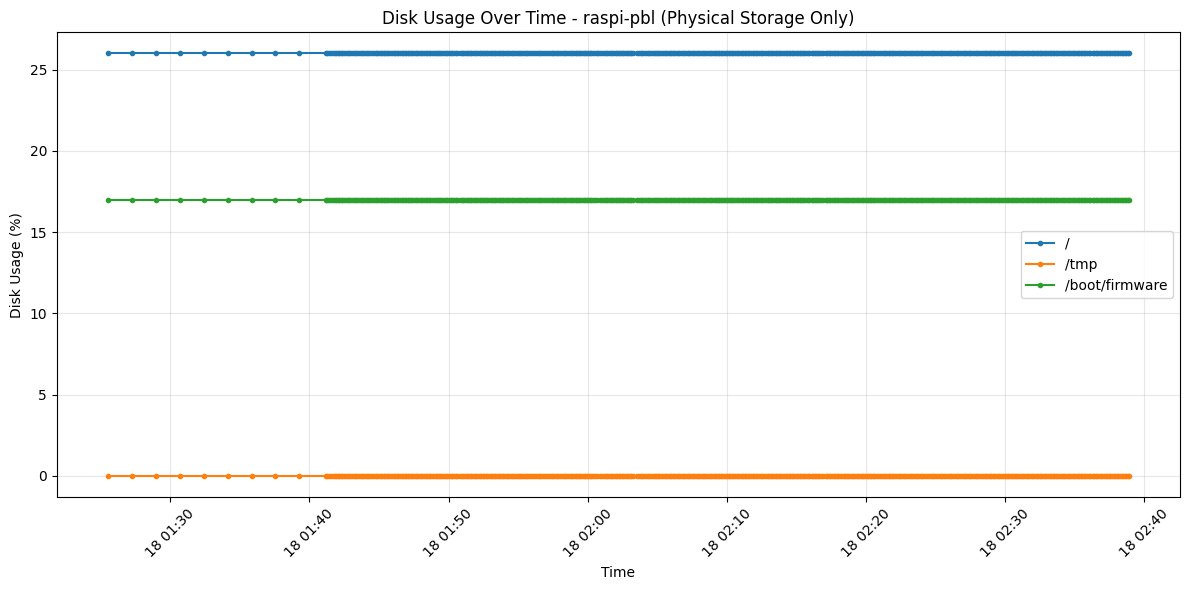

[DEBUG] Plotting disk I/O for raspi-pbl


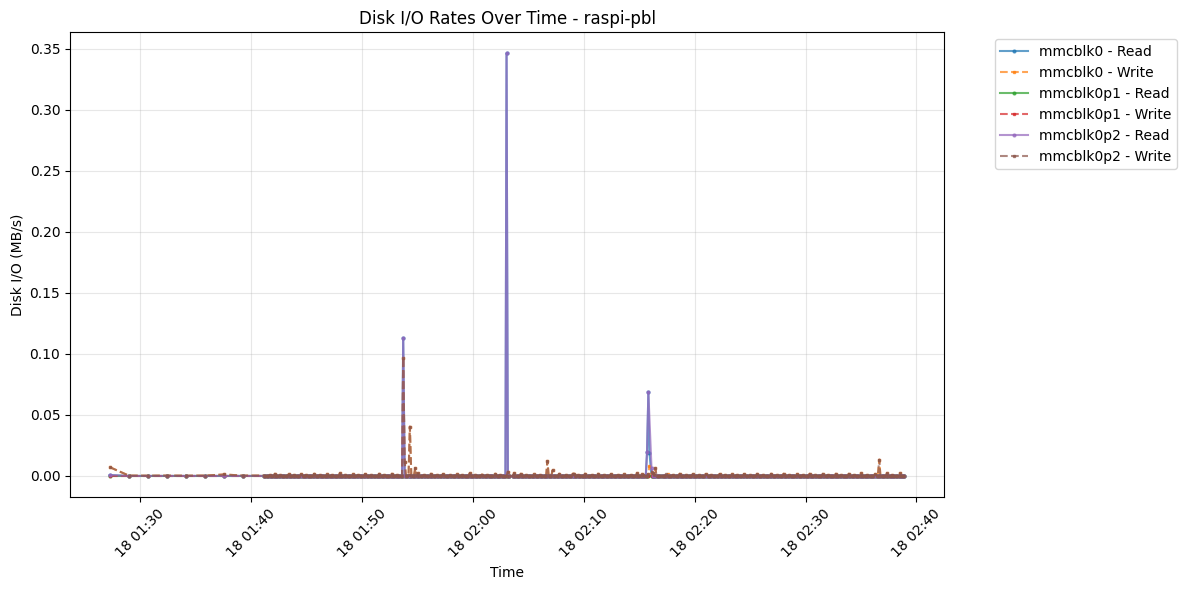

[DEBUG] Plotting CPU vs Network interaction for raspi-pbl


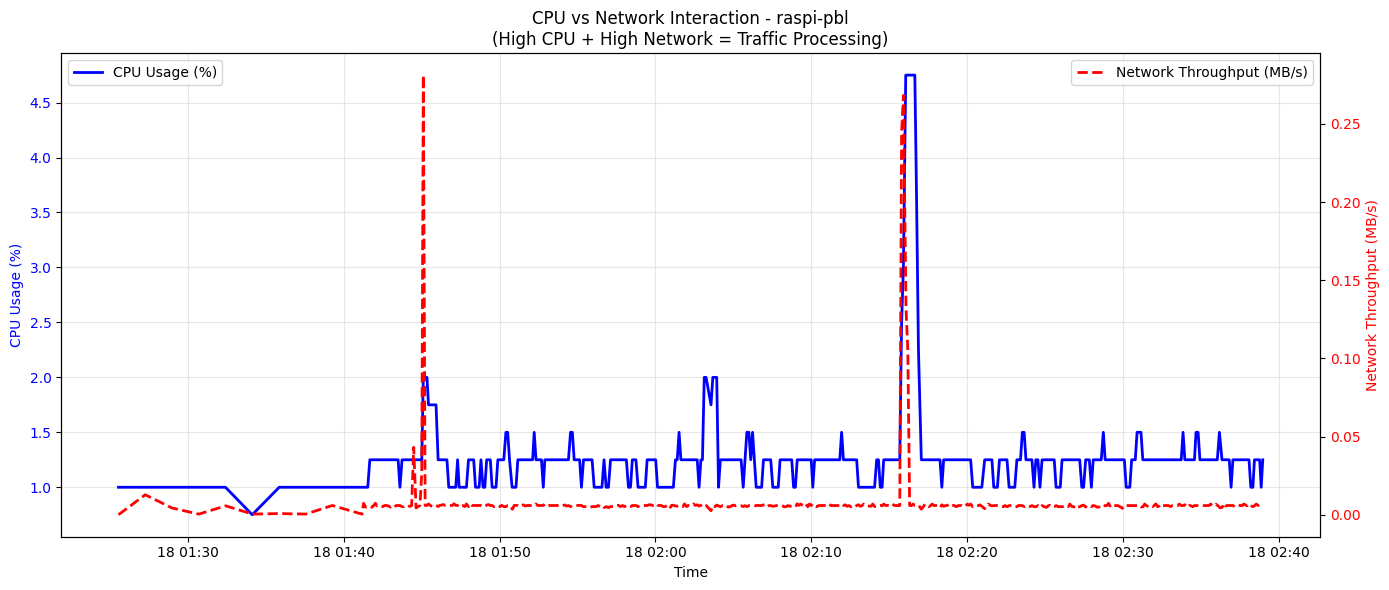

[DEBUG] Plotting Load vs CPU interaction for raspi-pbl


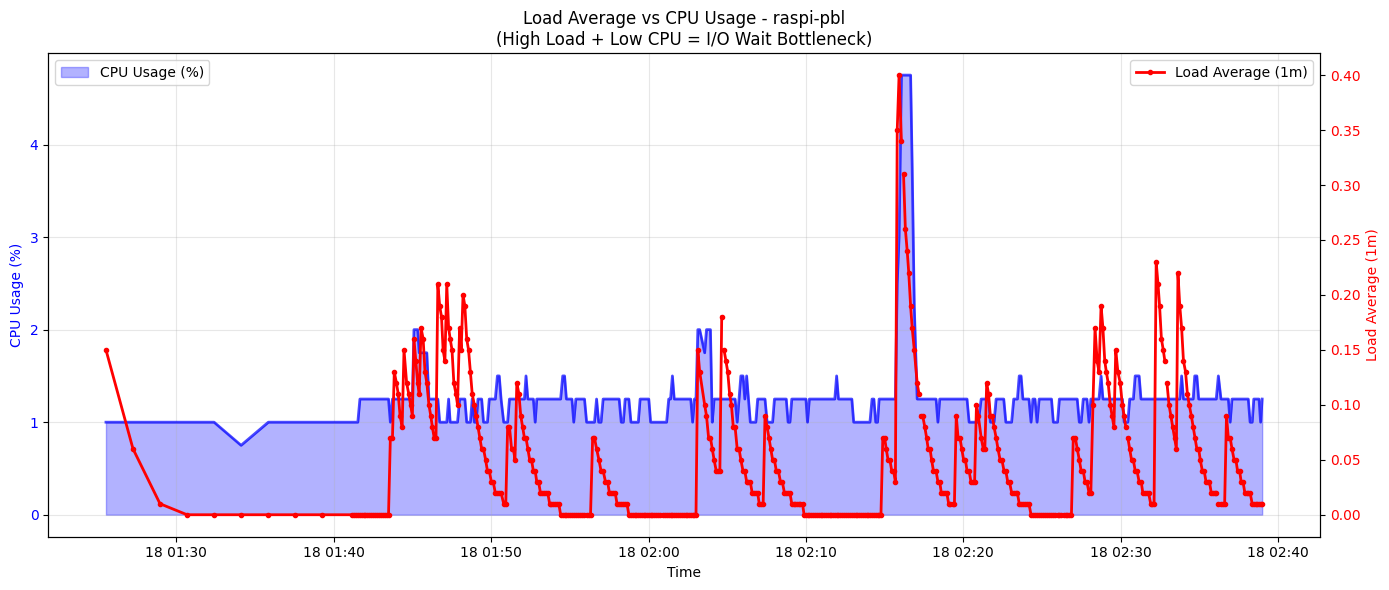

[DEBUG] Creating summary dataframe for correlation analysis
[DEBUG] Summary dataframe created with 0 time points and 8 metrics
[DEBUG] All advanced visualizations generated


In [66]:
if first_sysname:
    # Load disk I/O data for new visualization
    disk_io_df: pd.DataFrame = load_disk_io_counters(sysname=first_sysname, hours=hours)
    
    print(f"\n[DEBUG] Generating advanced visualizations for {first_sysname}")
    
    # Generate upgraded disk visualizations
    fig_disk_usage = plot_disk_usage(disk_df, first_sysname)
    plt.show()
    
    fig_disk_io = plot_disk_io(disk_io_df, first_sysname)
    plt.show()
    
    # Generate interaction graphs
    fig_cpu_network = plot_cpu_vs_network(cpu_df, network_df, first_sysname)
    plt.show()
    
    fig_load_cpu = plot_load_vs_cpu(load_avg_df, cpu_df, first_sysname)
    plt.show()
    
    # Create summary dataframe for correlation analysis
    summary_df: pd.DataFrame = create_summary_dataframe(
        cpu_df, memory_df, load_avg_df, network_df, temp_df, disk_io_df
    )
    
    if not summary_df.empty:
        # Generate correlation heatmap
        fig_corr = create_correlation_heatmap(summary_df, first_sysname)
        plt.show()
        
        # Generate diagnostic pairplot
        fig_pairplot = create_diagnostic_pairplot(summary_df, first_sysname)
        plt.show()
    
    print("[DEBUG] All advanced visualizations generated")

In [67]:
def get_sysnames_with_data(diagnosis_result: Dict[str, any]) -> List[str]:
    """Get list of all sysnames that have metrics data."""
    sysnames_with_data: set = set()
    if 'tables' in diagnosis_result:
        for table_info in diagnosis_result['tables'].values():
            if table_info['total_records'] > 0:
                sysnames_with_data.update(table_info['sysnames'])
    return sorted(list(sysnames_with_data))

In [68]:
# Get first available device WITH DATA for detailed exploration
# Priority: Use sysname that has metrics data, not just registered in devices table
first_sysname: Optional[str] = None

# Get all sysnames that have actual data
sysnames_with_data: List[str] = get_sysnames_with_data(diagnosis)
print(f"[DEBUG] Sysnames with metrics data: {sysnames_with_data}")

if sysnames_with_data:
    first_sysname = sysnames_with_data[0]
    print(f"[DEBUG] Using sysname '{first_sysname}' for exploration (has metrics data)")
else:
    # Fall back to devices table if no metrics data found
    if not devices_df.empty:
        first_sysname = devices_df.iloc[0]['sysname']
        print(f"[DEBUG] WARNING: No metrics data found. Using device '{first_sysname}' from devices table")
        print(f"[DEBUG] Available devices: {devices_df['sysname'].tolist()}")
    else:
        print("[DEBUG] ERROR: No devices found in database and no metrics data available")

[DEBUG] Sysnames with metrics data: ['raspi-pbl']
[DEBUG] Using sysname 'raspi-pbl' for exploration (has metrics data)


## Visualization Functions

Pure functions for creating visualizations that can be reused in web app.

In [69]:
def plot_load_averages(df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Plot load averages over time."""
    print(f"[DEBUG] Plotting load averages for {sysname}")
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if not df.empty and 'time' in df.columns:
        ax.plot(df['time'], df['load_1m'], label='1 minute', marker='o', markersize=3)
        ax.plot(df['time'], df['load_5m'], label='5 minutes', marker='s', markersize=3)
        ax.plot(df['time'], df['load_15m'], label='15 minutes', marker='^', markersize=3)
        ax.set_xlabel('Time')
        ax.set_ylabel('Load Average')
        ax.set_title(f'Load Averages Over Time - {sysname}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
    
    return fig

def plot_cpu_usage(df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Plot CPU usage per core over time."""
    print(f"[DEBUG] Plotting CPU usage for {sysname}")
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if not df.empty and 'time' in df.columns and 'cpu' in df.columns:
        for cpu in df['cpu'].unique():
            cpu_df = df[df['cpu'] == cpu]
            ax.plot(cpu_df['time'], cpu_df['percent'], label=f'CPU {cpu}', marker='o', markersize=2)
        ax.set_xlabel('Time')
        ax.set_ylabel('CPU Usage (%)')
        ax.set_title(f'CPU Usage Over Time - {sysname}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
    
    return fig

def plot_memory_usage(df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Plot memory usage over time."""
    print(f"[DEBUG] Plotting memory usage for {sysname}")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    if not df.empty and 'time' in df.columns:
        # Memory usage percentage
        ax1.plot(df['time'], df['percent'], label='Memory %', color='blue', marker='o', markersize=3)
        ax1.set_xlabel('Time')
        ax1.set_ylabel('Memory Usage (%)')
        ax1.set_title(f'Memory Usage Percentage - {sysname}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.tick_params(axis='x', rotation=45)
        
        # Memory breakdown
        if 'used' in df.columns and 'free' in df.columns and 'cached' in df.columns:
            ax2.stackplot(df['time'], 
                         df['used'] / 1e9, 
                         df['free'] / 1e9,
                         df['cached'] / 1e9 if 'cached' in df.columns else 0,
                         labels=['Used', 'Free', 'Cached'],
                         alpha=0.7)
            ax2.set_xlabel('Time')
            ax2.set_ylabel('Memory (GB)')
            ax2.set_title(f'Memory Breakdown - {sysname}')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            ax2.tick_params(axis='x', rotation=45)
    else:
        ax1.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax1.transAxes)
        ax2.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax2.transAxes)
    
    plt.tight_layout()
    return fig

def plot_disk_usage(df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Plot disk usage per mount point."""
    print(f"[DEBUG] Plotting disk usage for {sysname}")
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if not df.empty and 'time' in df.columns and 'mount' in df.columns:
        for mount in df['mount'].unique():
            mount_df = df[df['mount'] == mount]
            if 'percent' in mount_df.columns:
                ax.plot(mount_df['time'], mount_df['percent'], label=f'{mount}', marker='o', markersize=3)
        ax.set_xlabel('Time')
        ax.set_ylabel('Disk Usage (%)')
        ax.set_title(f'Disk Usage Over Time - {sysname}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
    
    return fig

def plot_network_io(df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Plot network I/O over time."""
    print(f"[DEBUG] Plotting network I/O for {sysname}")
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if not df.empty and 'time' in df.columns and 'iface' in df.columns:
        for iface in df['iface'].unique():
            iface_df = df[df['iface'] == iface]
            if 'bytes_sent' in iface_df.columns:
                ax.plot(iface_df['time'], iface_df['bytes_sent'] / 1e6, 
                       label=f'{iface} - Sent', linestyle='-', marker='o', markersize=2)
            if 'bytes_recv' in iface_df.columns:
                ax.plot(iface_df['time'], iface_df['bytes_recv'] / 1e6, 
                       label=f'{iface} - Received', linestyle='--', marker='s', markersize=2)
        ax.set_xlabel('Time')
        ax.set_ylabel('Network I/O (MB)')
        ax.set_title(f'Network I/O Over Time - {sysname}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
    
    return fig

def plot_temperature(df: pd.DataFrame, sysname: str) -> plt.Figure:
    """Plot CPU temperature over time."""
    print(f"[DEBUG] Plotting temperature for {sysname}")
    fig, ax = plt.subplots(figsize=(12, 6))
    
    if not df.empty and 'time' in df.columns and 'cpu_temp' in df.columns:
        ax.plot(df['time'], df['cpu_temp'], label='CPU Temperature', color='red', marker='o', markersize=3)
        ax.set_xlabel('Time')
        ax.set_ylabel('Temperature (°C)')
        ax.set_title(f'CPU Temperature Over Time - {sysname}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
    else:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
    
    return fig

## Generate Visualizations

Create visualizations for the first available device.

In [70]:
def get_data_time_range(sysname: str) -> Dict[str, Optional[datetime]]:
    """Get the actual time range of data for a sysname."""
    print(f"[DEBUG] Checking time range for sysname '{sysname}'")
    result: Dict[str, Optional[datetime]] = {'earliest': None, 'latest': None}
    
    with get_db() as conn:
        with conn.cursor() as cur:
            # Check multiple tables to find overall time range
            tables: List[str] = ['load_avg', 'cpu_percent', 'memory', 'disk_usage', 'net_io_counters', 'temperature']
            all_times: List[datetime] = []
            
            for table in tables:
                cur.execute(f"""
                    SELECT MIN(time) as min_time, MAX(time) as max_time
                    FROM {table}
                    WHERE sysname = %s
                """, (sysname,))
                row: Dict = cur.fetchone()
                if row and row.get('min_time'):
                    all_times.append(row['min_time'])
                if row and row.get('max_time'):
                    all_times.append(row['max_time'])
            
            if all_times:
                result['earliest'] = min(all_times)
                result['latest'] = max(all_times)
                print(f"[DEBUG] Data time range: {result['earliest']} to {result['latest']}")
                now: datetime = datetime.now()
                if result['latest']:
                    age_hours: float = (now - result['latest']).total_seconds() / 3600
                    print(f"[DEBUG] Latest data is {age_hours:.1f} hours old")
            else:
                print(f"[DEBUG] No time data found for '{sysname}'")
    
    return result

In [71]:
if first_sysname:
    # Check actual time range of data
    time_range: Dict[str, Optional[datetime]] = get_data_time_range(first_sysname)
    
    # Determine appropriate hours parameter
    hours: Optional[int] = None
    if time_range['latest']:
        now: datetime = datetime.now()
        age_hours: float = (now - time_range['latest']).total_seconds() / 3600
        
        if age_hours <= 24:
            hours = 24
            print(f"[DEBUG] Using hours=24 (data is recent)")
        elif age_hours <= 168:  # 7 days
            hours = 168
            print(f"[DEBUG] Using hours=168 (7 days) - data is {age_hours:.1f} hours old")
        elif age_hours <= 720:  # 30 days
            hours = 720
            print(f"[DEBUG] Using hours=720 (30 days) - data is {age_hours:.1f} hours old")
        else:
            hours = None
            print(f"[DEBUG] Using hours=None (load all data) - data is {age_hours:.1f} hours old")
    else:
        hours = None
        print(f"[DEBUG] Using hours=None (no time range found, loading all data)")
    
    # Load data for visualization
    load_avg_df: pd.DataFrame = load_load_avg(sysname=first_sysname, hours=hours)
    cpu_df: pd.DataFrame = load_cpu_percent(sysname=first_sysname, hours=hours)
    memory_df: pd.DataFrame = load_memory(sysname=first_sysname, hours=hours)
    disk_df: pd.DataFrame = load_disk_usage(sysname=first_sysname, hours=hours)
    network_df: pd.DataFrame = load_net_io_counters(sysname=first_sysname, hours=hours)
    temp_df: pd.DataFrame = load_temperature(sysname=first_sysname, hours=hours)
    
    print(f"\n[DEBUG] Data loaded for visualization (hours={hours})")
    print(f"  Load avg records: {len(load_avg_df)}")
    print(f"  CPU records: {len(cpu_df)}")
    print(f"  Memory records: {len(memory_df)}")
    print(f"  Disk records: {len(disk_df)}")
    print(f"  Network records: {len(network_df)}")
    print(f"  Temperature records: {len(temp_df)}")

[DEBUG] Checking time range for sysname 'raspi-pbl'
[DEBUG] Creating connection to localhost:3306/metrics
[DEBUG] Data time range: 2025-11-18 01:25:32 to 2025-11-18 02:39:00
[DEBUG] Latest data is 610.6 hours old
[DEBUG] Using hours=720 (30 days) - data is 610.6 hours old
[DEBUG] Loading load_avg for sysname=raspi-pbl, hours=720
[DEBUG] Creating connection to localhost:3306/metrics
[DEBUG] Loaded 500 load_avg records
  Time range: 2025-11-18 01:25:32 to 2025-11-18 02:38:59
[DEBUG] Loading cpu_percent for sysname=raspi-pbl, hours=720
[DEBUG] Creating connection to localhost:3306/metrics
[DEBUG] Loaded 1960 cpu_percent records
  Time range: 2025-11-18 01:25:32 to 2025-11-18 02:38:59
[DEBUG] Loading memory for sysname=raspi-pbl, hours=720
[DEBUG] Creating connection to localhost:3306/metrics
[DEBUG] Loaded 490 memory records
  Time range: 2025-11-18 01:25:32 to 2025-11-18 02:38:59
[DEBUG] Loading disk_usage for sysname=raspi-pbl, hours=720
[DEBUG] Creating connection to localhost:3306/met

[DEBUG] Plotting load averages for raspi-pbl


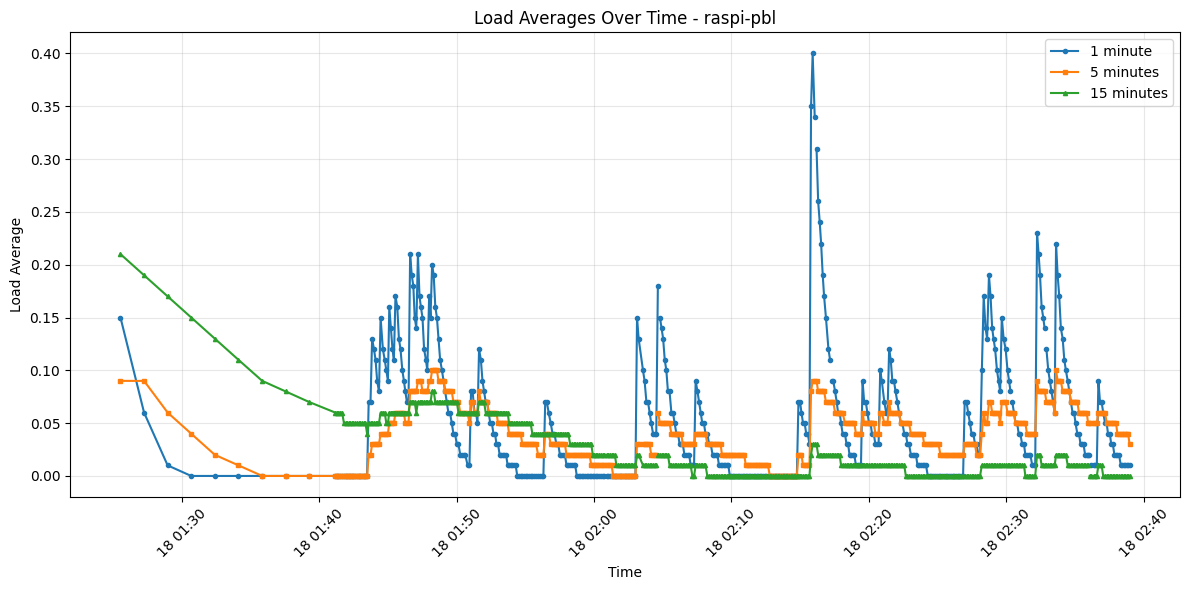

[DEBUG] Plotting CPU usage for raspi-pbl


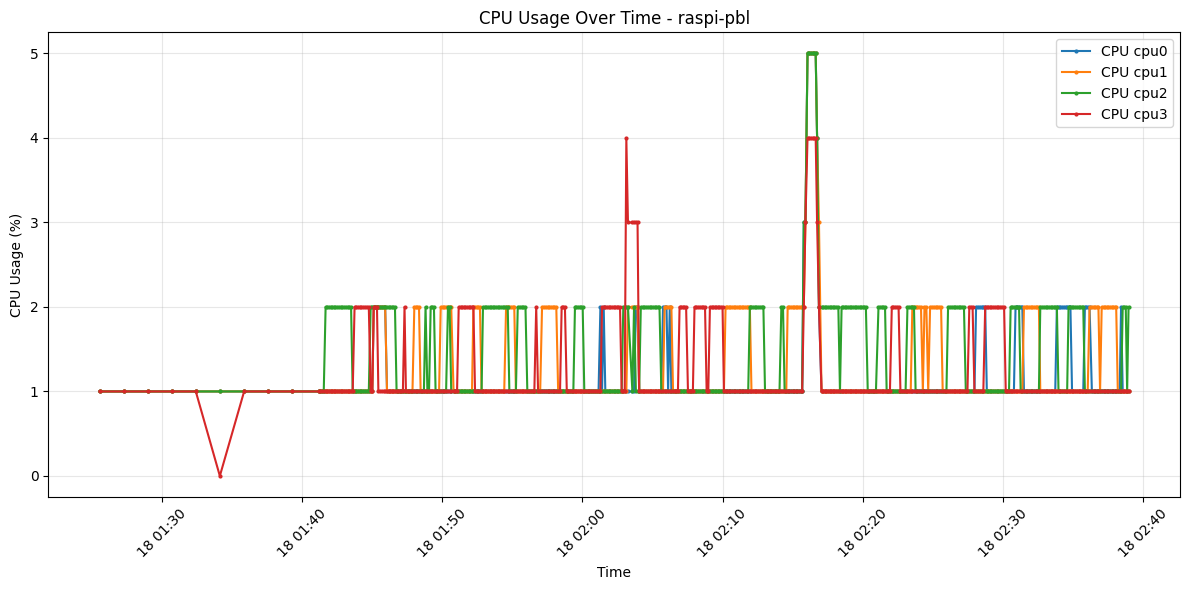

[DEBUG] Plotting memory usage for raspi-pbl


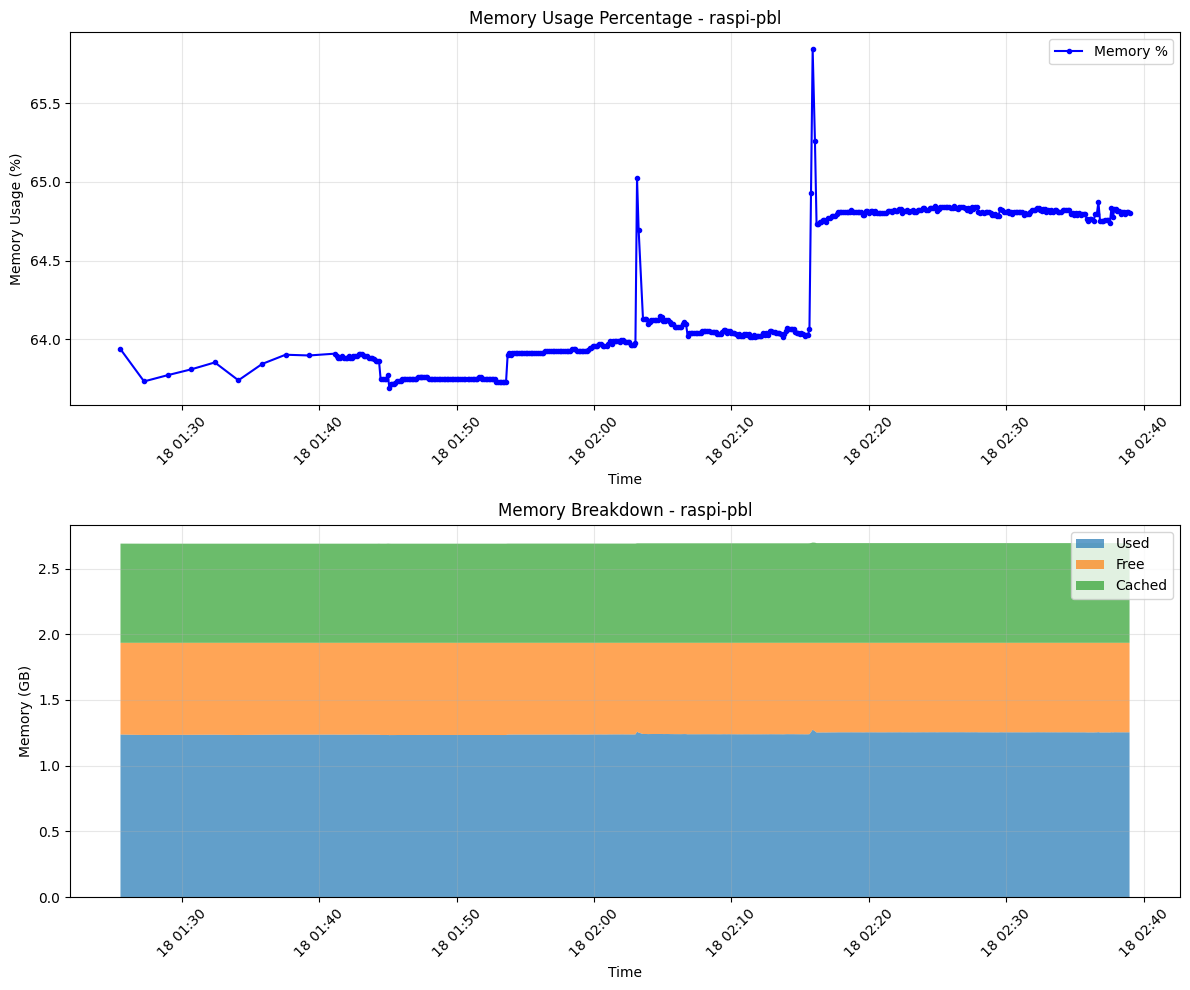

[DEBUG] Plotting disk usage for raspi-pbl


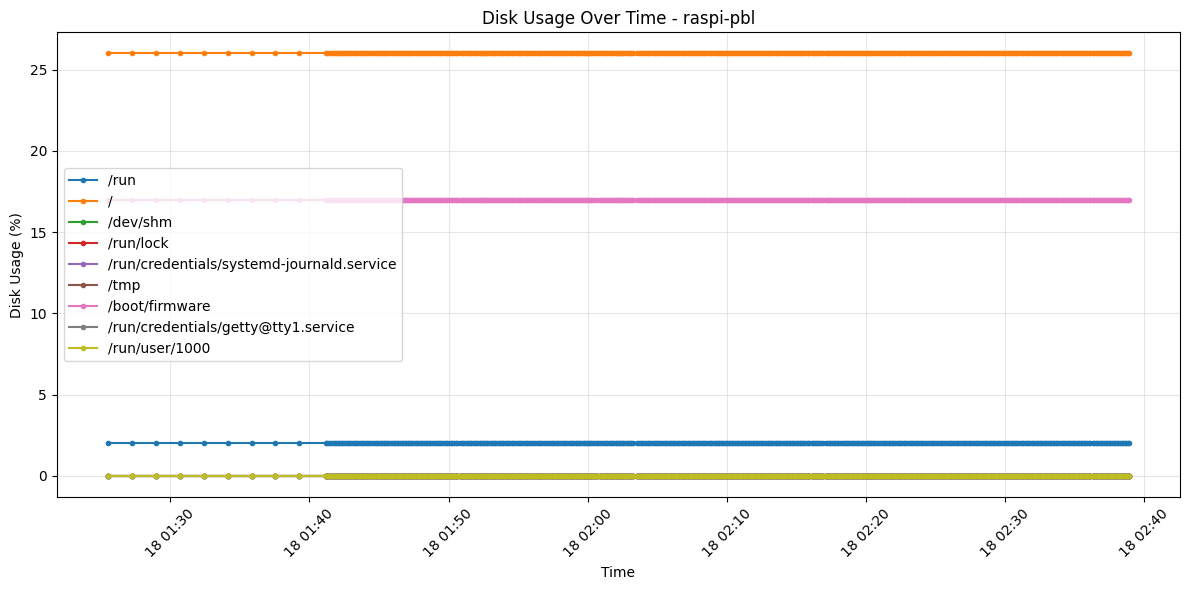

[DEBUG] Plotting network I/O for raspi-pbl


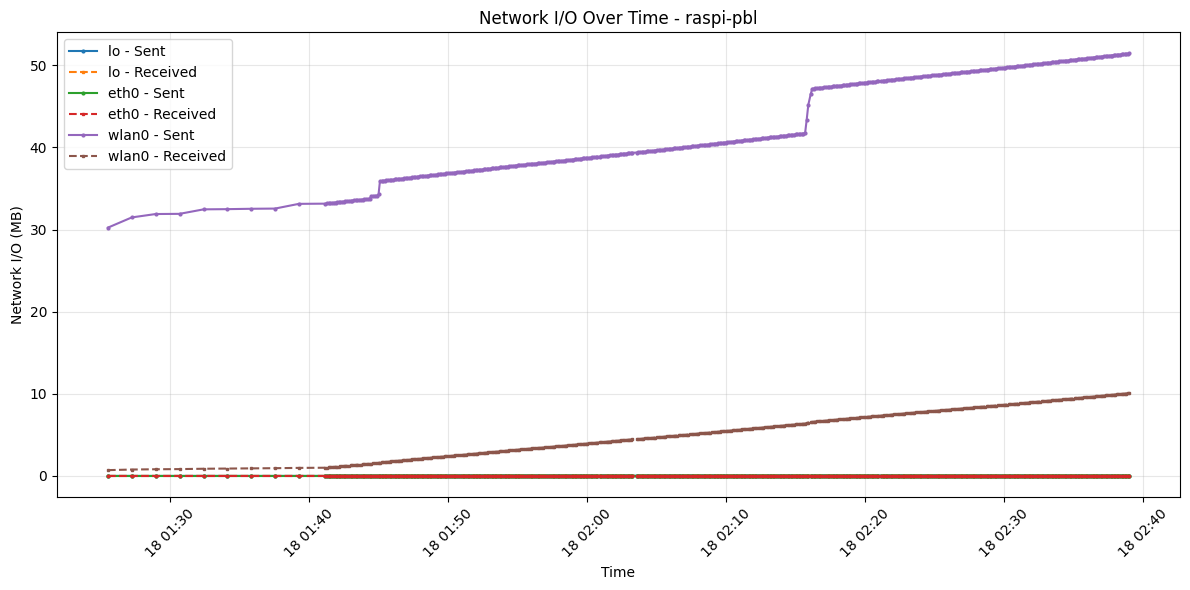

[DEBUG] Plotting temperature for raspi-pbl


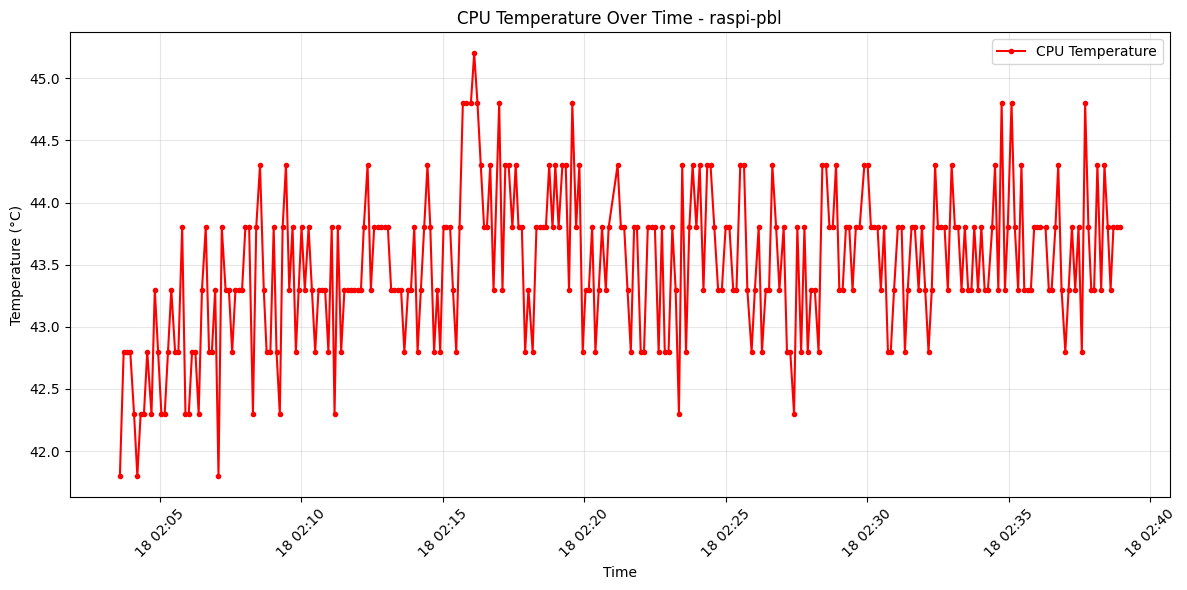

[DEBUG] All visualizations generated


In [72]:
if first_sysname:
    # Generate all visualizations
    fig1 = plot_load_averages(load_avg_df, first_sysname)
    plt.show()
    
    fig2 = plot_cpu_usage(cpu_df, first_sysname)
    plt.show()
    
    fig3 = plot_memory_usage(memory_df, first_sysname)
    plt.show()
    
    fig4 = plot_disk_usage(disk_df, first_sysname)
    plt.show()
    
    fig5 = plot_network_io(network_df, first_sysname)
    plt.show()
    
    fig6 = plot_temperature(temp_df, first_sysname)
    plt.show()
    
    print("[DEBUG] All visualizations generated")

## Data Statistics and Summary

Calculate summary statistics for understanding data distribution and patterns.

In [73]:
def calculate_summary_stats(df: pd.DataFrame, metric_cols: List[str]) -> pd.DataFrame:
    """Calculate summary statistics for specified metric columns."""
    print(f"[DEBUG] Calculating summary stats for columns: {metric_cols}")
    if df.empty:
        return pd.DataFrame()
    
    available_cols: List[str] = [col for col in metric_cols if col in df.columns]
    if not available_cols:
        return pd.DataFrame()
    
    stats: pd.DataFrame = df[available_cols].describe()
    return stats

if first_sysname:
    # Summary statistics for each metric type
    print("\n[DEBUG] Load Average Statistics:")
    print(calculate_summary_stats(load_avg_df, ['load_1m', 'load_5m', 'load_15m']))
    
    print("\n[DEBUG] CPU Usage Statistics:")
    print(calculate_summary_stats(cpu_df, ['percent']))
    
    print("\n[DEBUG] Memory Usage Statistics:")
    print(calculate_summary_stats(memory_df, ['percent', 'used', 'free', 'cached']))
    
    print("\n[DEBUG] Disk Usage Statistics:")
    print(calculate_summary_stats(disk_df, ['percent', 'used', 'free']))
    
    print("\n[DEBUG] Network I/O Statistics:")
    print(calculate_summary_stats(network_df, ['bytes_sent', 'bytes_recv']))
    
    print("\n[DEBUG] Temperature Statistics:")
    print(calculate_summary_stats(temp_df, ['cpu_temp']))


[DEBUG] Load Average Statistics:
[DEBUG] Calculating summary stats for columns: ['load_1m', 'load_5m', 'load_15m']
          load_1m     load_5m    load_15m
count  490.000000  490.000000  490.000000
mean     0.050694    0.040327    0.024510
std      0.061247    0.025707    0.028684
min      0.000000    0.000000    0.000000
25%      0.000000    0.020000    0.000000
50%      0.030000    0.040000    0.010000
75%      0.080000    0.060000    0.050000
max      0.400000    0.100000    0.210000

[DEBUG] CPU Usage Statistics:
[DEBUG] Calculating summary stats for columns: ['percent']
           percent
count  1960.000000
mean      1.275510
std       0.595724
min       0.000000
25%       1.000000
50%       1.000000
75%       1.000000
max       5.000000

[DEBUG] Memory Usage Statistics:
[DEBUG] Calculating summary stats for columns: ['percent', 'used', 'free', 'cached']
          percent          used          free        cached
count  490.000000  4.900000e+02  4.900000e+02  4.900000e+02
mean  

## Data Quality Checks

Check for missing data, outliers, and data consistency.

In [74]:
def check_data_quality(df: pd.DataFrame, name: str) -> Dict[str, any]:
    """Check data quality metrics."""
    print(f"[DEBUG] Checking data quality for {name}")
    result: Dict[str, any] = {
        'total_records': len(df),
        'missing_values': {},
        'duplicate_timestamps': 0
    }
    
    if not df.empty:
        result['missing_values'] = df.isnull().sum().to_dict()
        if 'time' in df.columns:
            result['duplicate_timestamps'] = df['time'].duplicated().sum()
        result['date_range'] = {
            'min': str(df['time'].min()) if 'time' in df.columns else None,
            'max': str(df['time'].max()) if 'time' in df.columns else None
        }
    
    return result

if first_sysname:
    quality_checks: Dict[str, Dict] = {
        'load_avg': check_data_quality(load_avg_df, 'load_avg'),
        'cpu': check_data_quality(cpu_df, 'cpu'),
        'memory': check_data_quality(memory_df, 'memory'),
        'disk': check_data_quality(disk_df, 'disk'),
        'network': check_data_quality(network_df, 'network'),
        'temperature': check_data_quality(temp_df, 'temperature')
    }
    
    for name, check in quality_checks.items():
        print(f"\n[DEBUG] {name} quality check:")
        for key, value in check.items():
            print(f"  {key}: {value}")

[DEBUG] Checking data quality for load_avg
[DEBUG] Checking data quality for cpu
[DEBUG] Checking data quality for memory
[DEBUG] Checking data quality for disk
[DEBUG] Checking data quality for network
[DEBUG] Checking data quality for temperature

[DEBUG] load_avg quality check:
  total_records: 500
  missing_values: {'id': 0, 'time': 0, 'sysname': 0, 'load_1m': 10, 'load_5m': 10, 'load_15m': 10}
  duplicate_timestamps: 0
  date_range: {'min': '2025-11-18 01:25:32', 'max': '2025-11-18 02:38:59'}

[DEBUG] cpu quality check:
  total_records: 1960
  missing_values: {'id': 0, 'time': 0, 'sysname': 0, 'cpu': 0, 'percent': 0}
  duplicate_timestamps: 1470
  date_range: {'min': '2025-11-18 01:25:32', 'max': '2025-11-18 02:38:59'}

[DEBUG] memory quality check:
  total_records: 490
  missing_values: {'id': 0, 'time': 0, 'sysname': 0, 'total': 0, 'available': 0, 'used': 0, 'free': 0, 'percent': 0, 'buffers': 0, 'cached': 0, 'shared': 0}
  duplicate_timestamps: 0
  date_range: {'min': '2025-11-

## Export Functions for Web App

Functions to prepare data in formats suitable for web app visualization libraries.

In [75]:
def prepare_time_series_data(df: pd.DataFrame, value_col: str, time_col: str = 'time') -> List[Dict[str, any]]:
    """Prepare time series data for web app (e.g., Chart.js format)."""
    print(f"[DEBUG] Preparing time series data for column {value_col}")
    if df.empty or value_col not in df.columns or time_col not in df.columns:
        return []
    
    data: List[Dict[str, any]] = []
    for _, row in df.iterrows():
        data.append({
            'time': row[time_col].isoformat() if pd.notna(row[time_col]) else None,
            'value': float(row[value_col]) if pd.notna(row[value_col]) else None
        })
    
    return data

def prepare_multi_series_data(df: pd.DataFrame, value_col: str, group_col: str, time_col: str = 'time') -> Dict[str, List[Dict[str, any]]]:
    """Prepare multi-series data grouped by a column (e.g., CPU per core)."""
    print(f"[DEBUG] Preparing multi-series data for {value_col} grouped by {group_col}")
    if df.empty or value_col not in df.columns or group_col not in df.columns or time_col not in df.columns:
        return {}
    
    result: Dict[str, List[Dict[str, any]]] = {}
    for group_value in df[group_col].unique():
        group_df = df[df[group_col] == group_value]
        result[str(group_value)] = prepare_time_series_data(group_df, value_col, time_col)
    
    return result

def prepare_gauge_data(df: pd.DataFrame, value_col: str) -> Optional[float]:
    """Prepare latest value for gauge visualization."""
    print(f"[DEBUG] Preparing gauge data for {value_col}")
    if df.empty or value_col not in df.columns:
        return None
    
    latest_value = df[value_col].iloc[-1] if len(df) > 0 else None
    return float(latest_value) if pd.notna(latest_value) else None

print("[DEBUG] Export functions defined for web app integration")

[DEBUG] Export functions defined for web app integration


## PDF Export Diagnostics

Check if LaTeX/xelatex is accessible for PDF export.

In [76]:
import subprocess
import shutil
import os

def check_latex_availability() -> Dict[str, any]:
    """Check if LaTeX tools are available for PDF export."""
    print("[DEBUG] Checking LaTeX availability for PDF export...")
    result: Dict[str, any] = {}
    
    # Check for xelatex
    xelatex_path = shutil.which('xelatex')
    result['xelatex_found'] = xelatex_path is not None
    result['xelatex_path'] = xelatex_path
    
    if xelatex_path:
        try:
            version_output = subprocess.run(
                ['xelatex', '--version'],
                capture_output=True,
                text=True,
                timeout=5
            )
            result['xelatex_version'] = version_output.stdout.split('\n')[0] if version_output.stdout else 'Unknown'
            print(f"[DEBUG] xelatex found at: {xelatex_path}")
        except Exception as e:
            result['xelatex_error'] = str(e)
            print(f"[DEBUG] Error checking xelatex: {e}")
    else:
        print("[DEBUG] xelatex not found in PATH")
    
    # Check PATH
    result['path'] = os.environ.get('PATH', '')
    print(f"[DEBUG] PATH length: {len(result['path'])} characters")
    
    return result

latex_check: Dict[str, any] = check_latex_availability()
print(f"\n[DEBUG] LaTeX availability check complete:")
for key, value in latex_check.items():
    if key != 'path':  # Don't print full PATH
        print(f"  {key}: {value}")

[DEBUG] Checking LaTeX availability for PDF export...
[DEBUG] xelatex found at: C:\Users\LAPTOP T&T\AppData\Local\Programs\MiKTeX\miktex\bin\x64\xelatex.EXE
[DEBUG] PATH length: 2183 characters

[DEBUG] LaTeX availability check complete:
  xelatex_found: True
  xelatex_path: C:\Users\LAPTOP T&T\AppData\Local\Programs\MiKTeX\miktex\bin\x64\xelatex.EXE
  xelatex_version: MiKTeX-XeTeX 4.10 (MiKTeX 24.1)
